# Telco Customer Churn — ML & Data Analytics Practice

---

## Business Problem

> **A telecom company wants to predict which customers are likely to cancel their subscription (churn) so the retention team can intervene before they leave.**

Customer churn is one of the most costly problems in subscription-based businesses. Acquiring a new customer costs 5–7x more than retaining an existing one. By predicting churn in advance, the business can:
- Proactively offer discounts or incentives to at-risk customers
- Prioritize outreach by churn probability score
- Understand *why* customers leave (contract type, pricing, service quality)

This is a **binary classification problem**: given a customer's account information and usage behavior, predict whether they will churn (`Yes`) or stay (`No`).

---

## Dataset Overview

**Source:** IBM Sample Data / [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

| Property | Details |
|---|---|
| Rows | ~7,043 customers |
| Columns | 21 features |
| Target variable | `Churn` (Yes / No) |
| Class balance | ~73% No Churn, ~27% Churn (imbalanced) |
| File format | CSV |

---

## Feature Breakdown

### Customer Demographics
| Column | Type | Description |
|---|---|---|
| `customerID` | String | Unique ID — drop before modeling |
| `gender` | Categorical | Male / Female |
| `SeniorCitizen` | Binary (0/1) | Whether the customer is a senior citizen |
| `Partner` | Categorical | Has a partner (Yes/No) |
| `Dependents` | Categorical | Has dependents (Yes/No) |

### Account Information
| Column | Type | Description |
|---|---|---|
| `tenure` | Numerical | Months the customer has been with the company |
| `Contract` | Categorical | Month-to-month / One year / Two year |
| `PaperlessBilling` | Categorical | Yes / No |
| `PaymentMethod` | Categorical | Electronic check, Mailed check, Bank transfer, Credit card |
| `MonthlyCharges` | Numerical | Current monthly charge amount |
| `TotalCharges` | Numerical (stored as string) | Total amount charged — **needs cleaning** |

### Services Subscribed
| Column | Type | Description |
|---|---|---|
| `PhoneService` | Categorical | Yes / No |
| `MultipleLines` | Categorical | Yes / No / No phone service |
| `InternetService` | Categorical | DSL / Fiber optic / No |
| `OnlineSecurity` | Categorical | Yes / No / No internet service |
| `OnlineBackup` | Categorical | Yes / No / No internet service |
| `DeviceProtection` | Categorical | Yes / No / No internet service |
| `TechSupport` | Categorical | Yes / No / No internet service |
| `StreamingTV` | Categorical | Yes / No / No internet service |
| `StreamingMovies` | Categorical | Yes / No / No internet service |

---

## Known Data Quality Issues (to fix during cleaning)

1. `TotalCharges` is stored as a **string** — contains whitespace entries that must be converted to `NaN` then imputed or dropped
2. `customerID` is a unique identifier — **useless for modeling, drop it**
3. `SeniorCitizen` is already encoded as 0/1 — all other binary columns need encoding
4. Class imbalance (~73/27 split) — must account for this during modeling (use `class_weight='balanced'` or evaluate with ROC-AUC, not just accuracy)

---

## ML Pipeline Plan

```
1. Load & inspect data       → shape, dtypes, .info(), .describe()
2. Data cleaning             → fix TotalCharges, handle nulls, drop customerID
3. EDA & visualizations      → churn rate by feature, distributions, correlation heatmap
4. Feature engineering       → encode categoricals, scale numericals
5. Train/test split          → 80/20, stratified on target
6. Model training            → Logistic Regression, Decision Tree, Random Forest
7. Evaluation                → Confusion matrix, Precision/Recall, ROC-AUC curve
8. Interpret results         → Feature importance, business recommendations
```

STEP 1. Loading and Inspecting the Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Load the data
telco=pd.read_csv('Telco-Customer-Churn.csv')

#telco.describe
telco.info()
telco.head()

# TotalCharges feature is treated as string, should be numeric.
telco['TotalCharges']=pd.to_numeric(telco['TotalCharges'],errors='coerce') #to numeric
print(telco['TotalCharges'].isnull().sum()) #check for nulls, bro had 11 null values, drop these rows later..

# X will be the features (but dropping the customerID column). Churn is the label (y).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Step 2. Initial Data Cleaning

In [4]:
#drop the rows with null values 
telco = telco.dropna()

#initial X and y
X=telco.drop(columns=['Churn','customerID'])
y=telco['Churn']

Step 3. EDA and Visualization

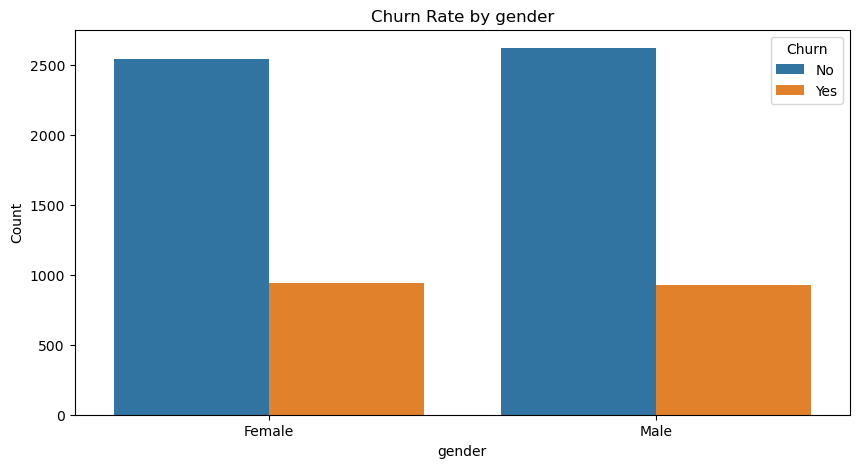

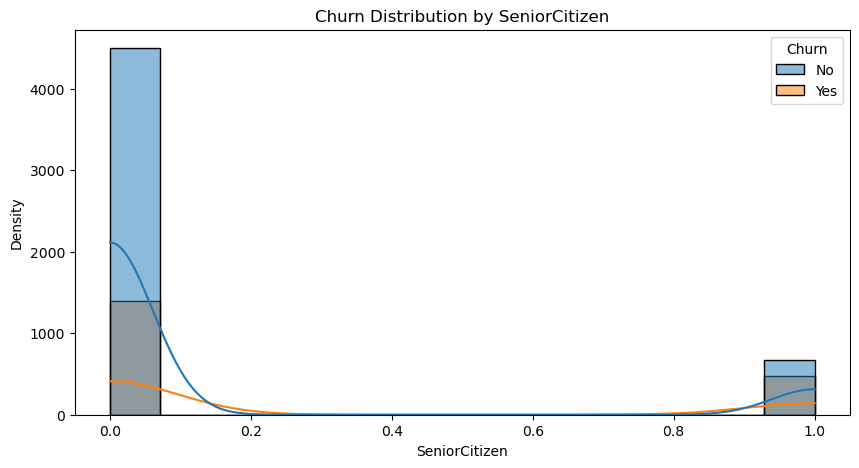

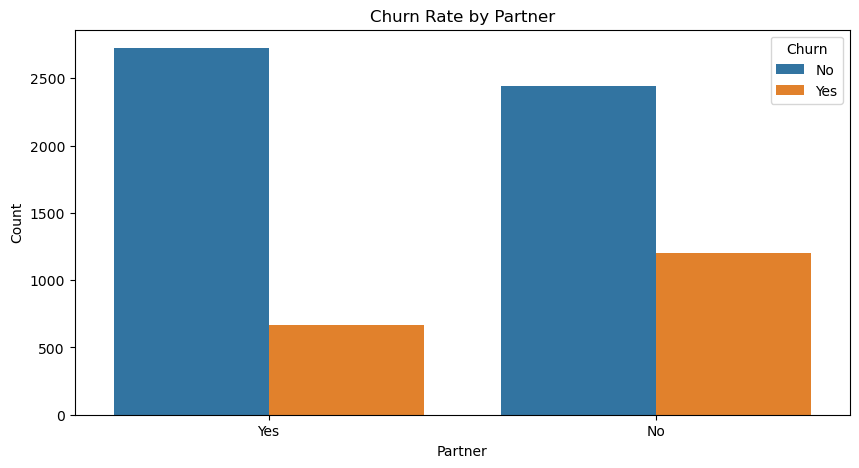

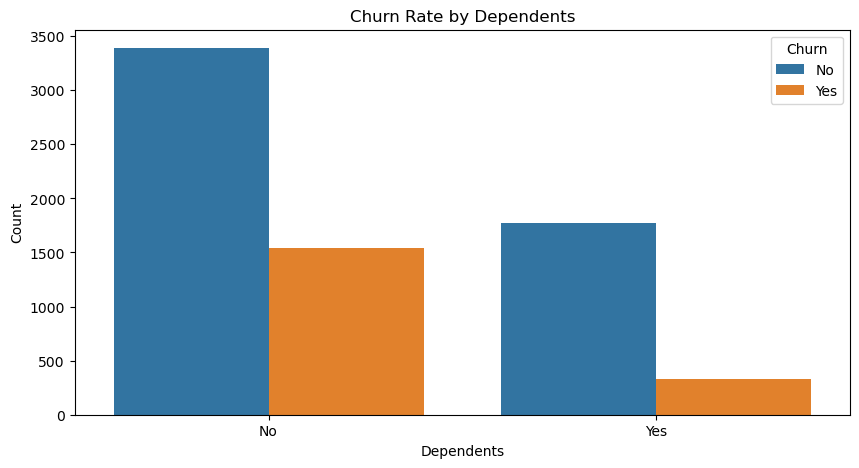

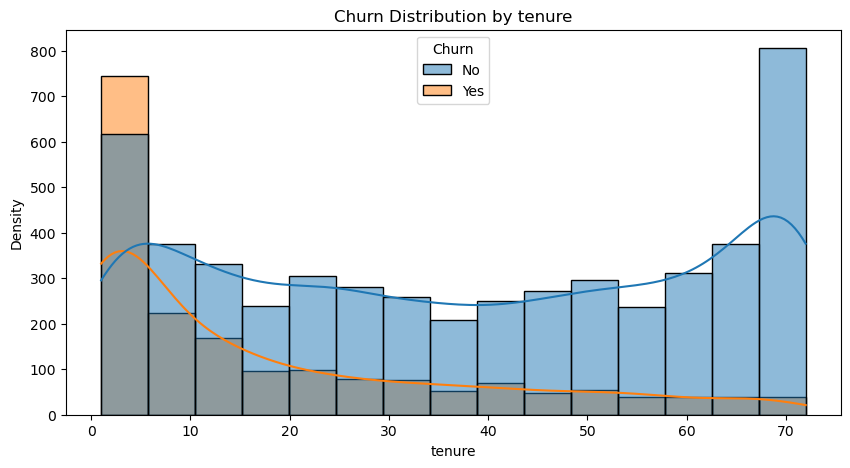

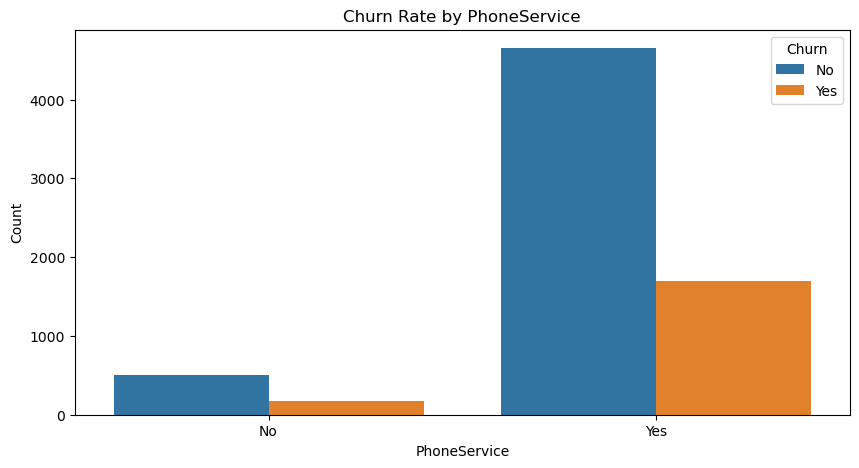

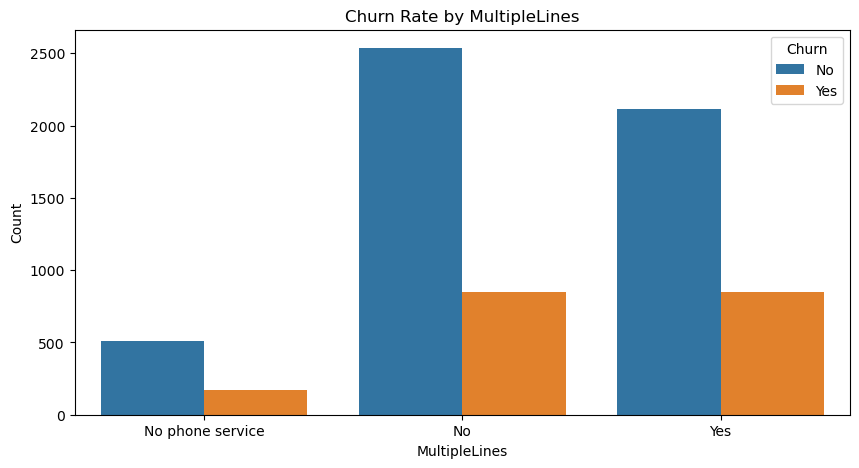

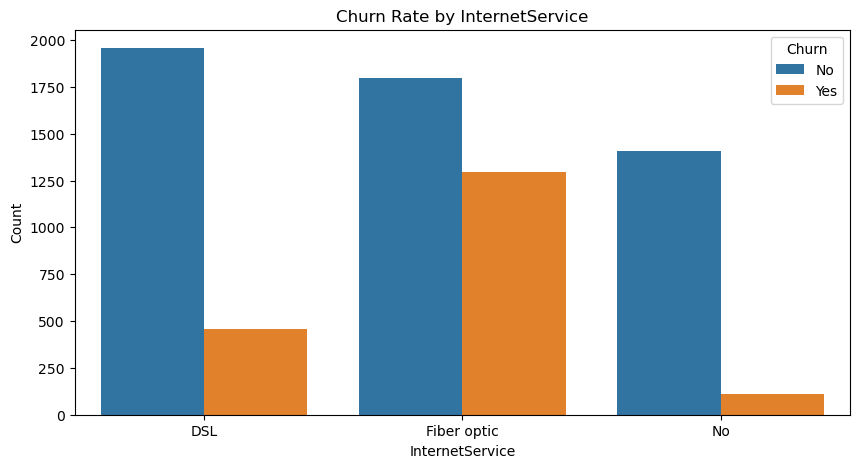

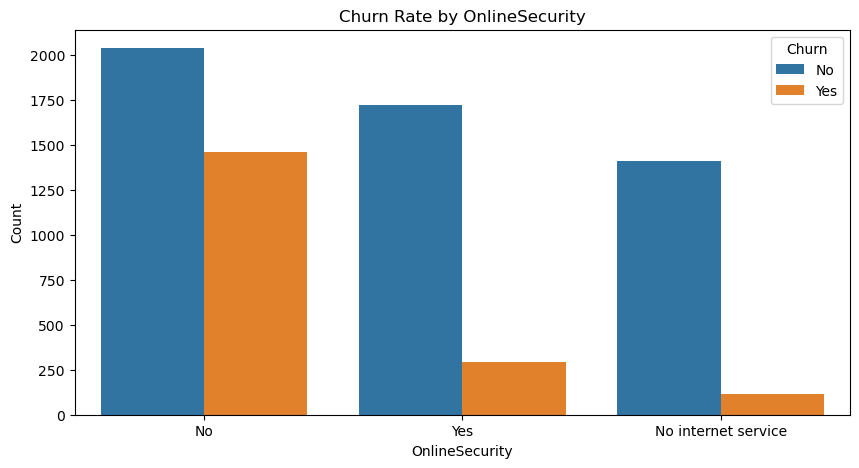

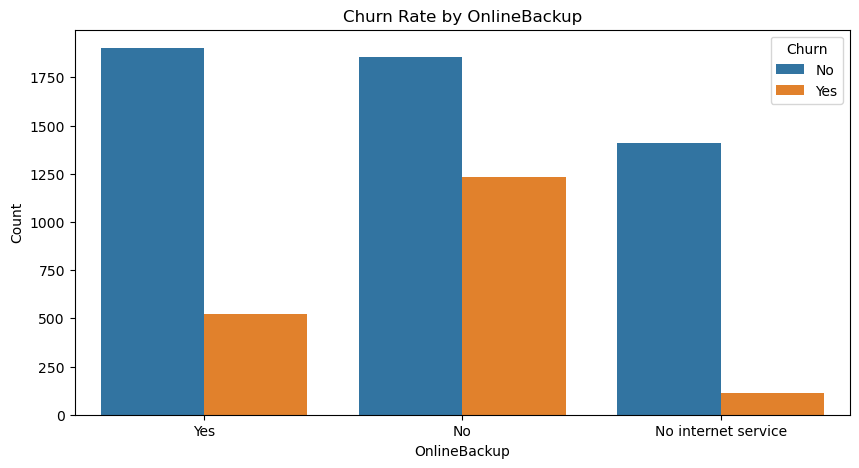

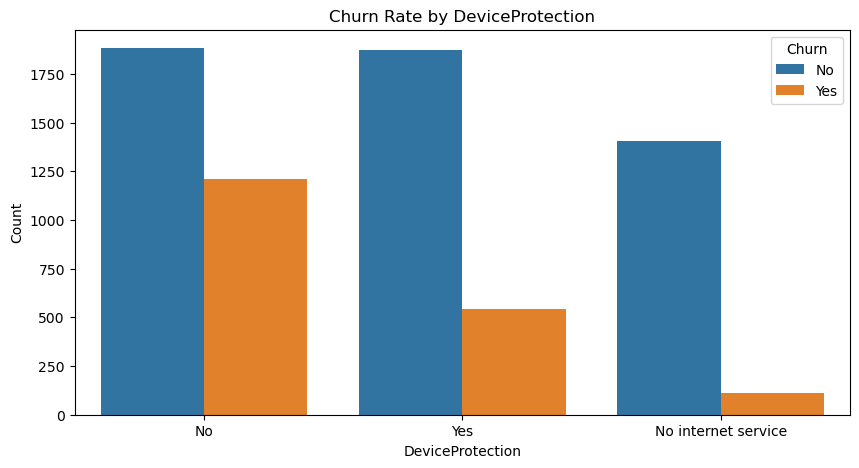

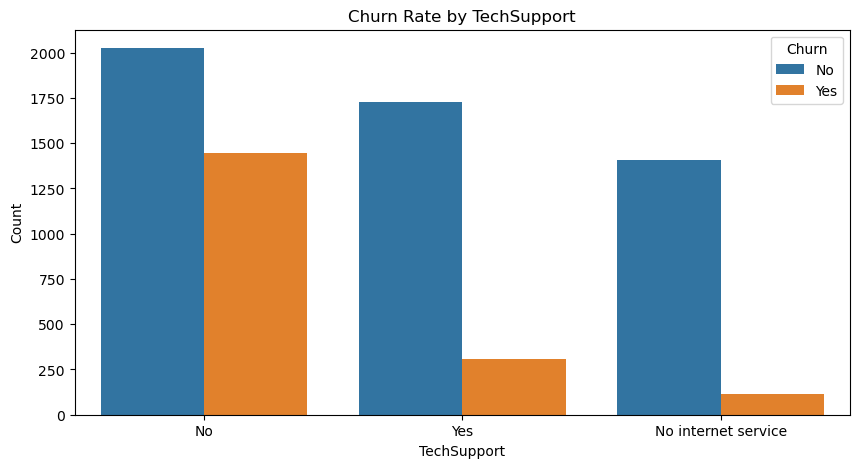

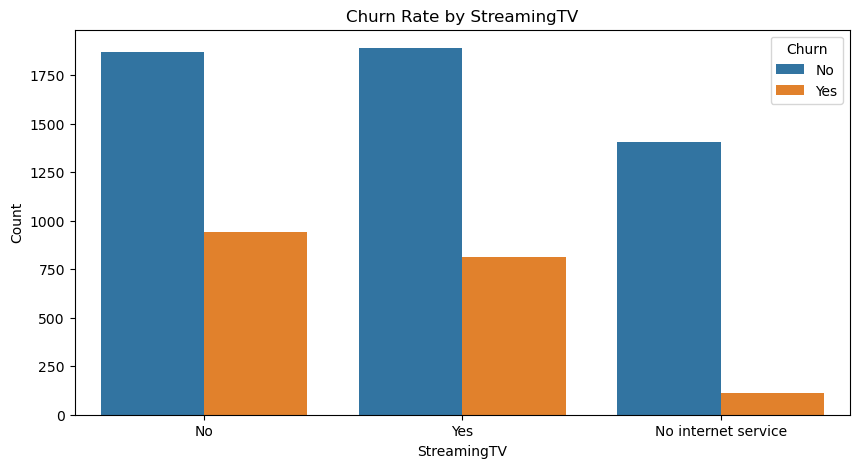

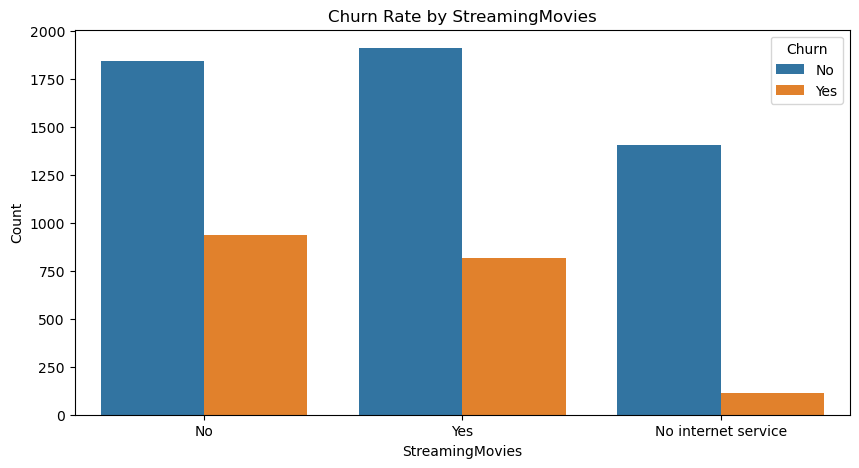

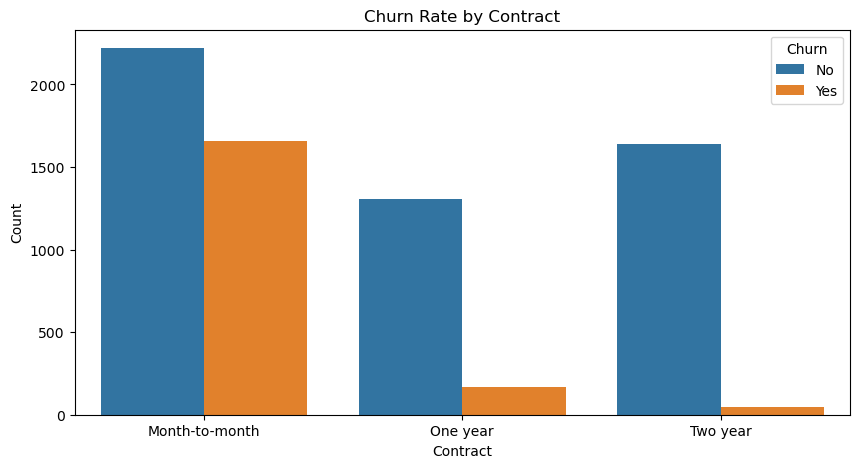

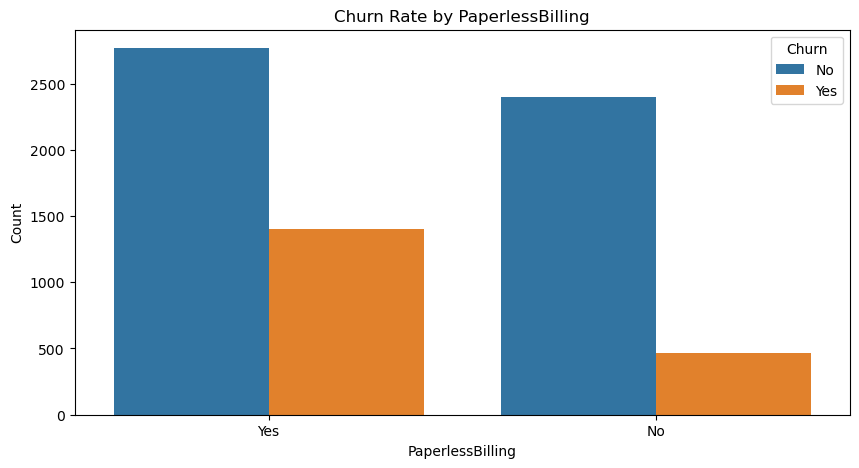

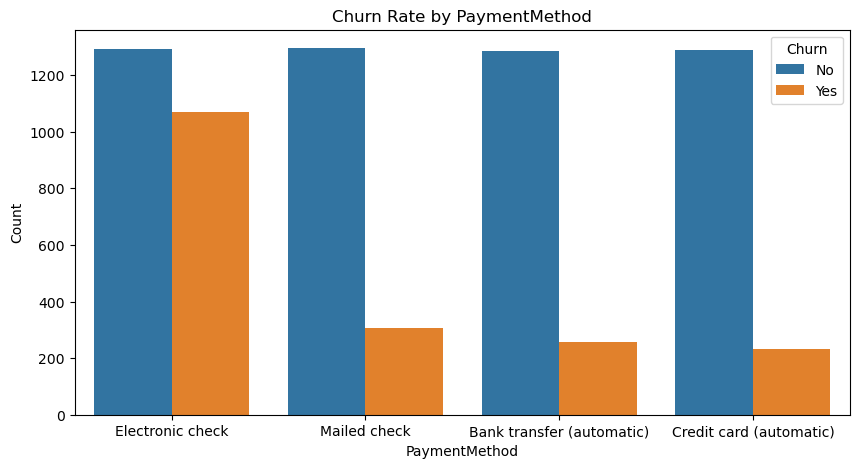

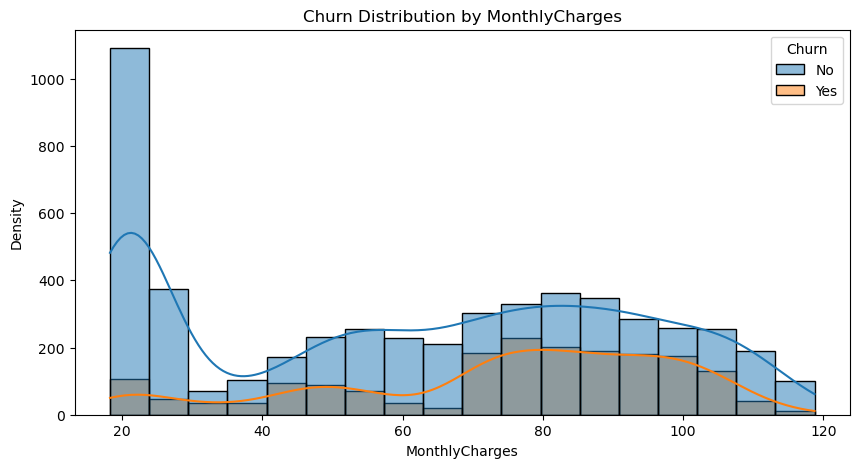

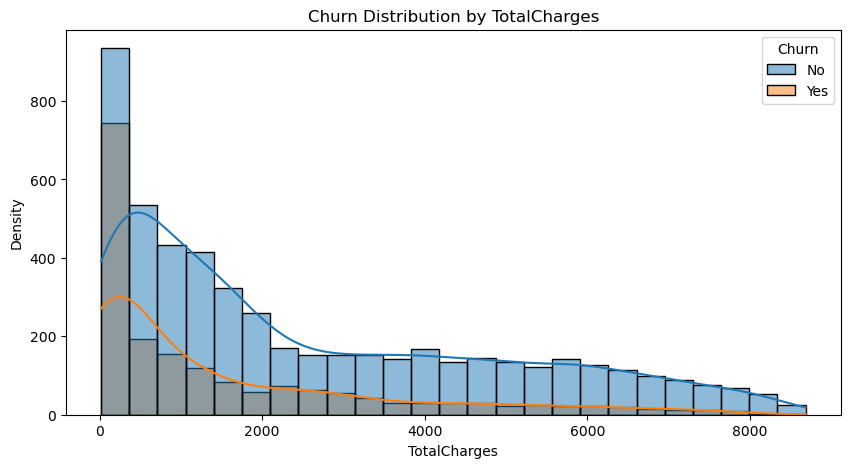

In [5]:
import seaborn as sns

#Plot churn rate by feature
for column in X.columns:
    plt.figure(figsize=(10,5))
    if X[column].dtype == 'object': #categoricals
        sns.countplot(x=X[column], hue=y)
        plt.title(f'Churn Rate by {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.legend(title='Churn', labels=['No', 'Yes'])
    else: #numericals
        sns.histplot(data=telco, x=column, hue='Churn', kde=True)
        plt.title(f'Churn Distribution by {column}')
        plt.xlabel(column)
        plt.ylabel('Density')
    plt.show()

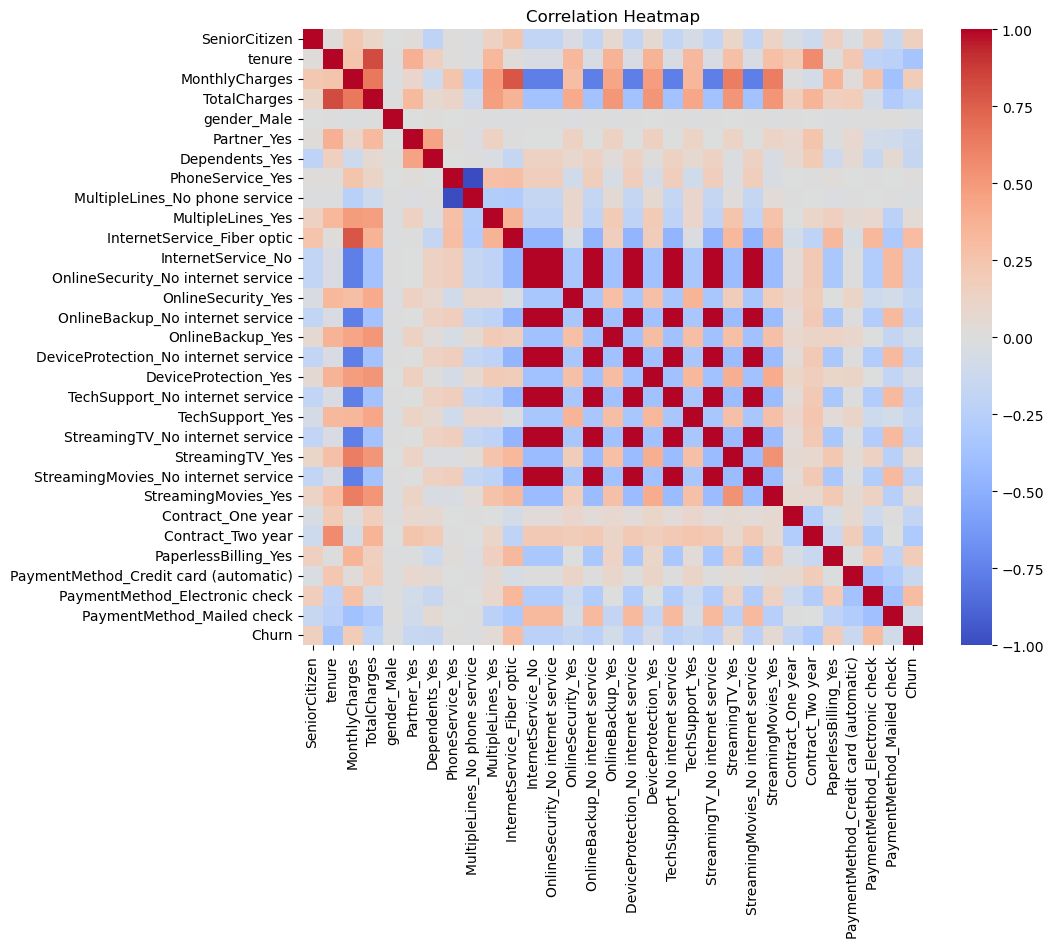

In [6]:
#plot heatmap of correlations
plt.figure(figsize=(10,8))
X_encoded = pd.get_dummies(X, drop_first=True) #encode categoricals for correlation
y_encoded = y.map({'No': 0, 'Yes': 1}) #encode target
sns.heatmap((X_encoded.join(y_encoded)).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Found Multicollinearity in 'tenure' and 'TotalCharges' since tenure*monthly charges=totalcharges, and others(but they make sense to be correlated).
#Looking at tenure and totalCharges, totalCharges has more correlation with churn, so dropping tenure.
X=X.drop(columns=['tenure'])

Step 4. Feature Engineering

In [7]:
#scaling the numerical features
from sklearn.preprocessing import StandardScaler
numerical_features = ['MonthlyCharges', 'TotalCharges']
scaler=StandardScaler()
X[numerical_features]=scaler.fit_transform(X[numerical_features])

#encoding the categorical features
X=pd.get_dummies(X, drop_first=True)
y=y.map({'No': 0, 'Yes': 1}) #encode target

Step 5. Train/Test Split - 80/20

In [8]:
#time to split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Step 6. Model Training and Interpretations

Since this is a Classification problem, we can try to use A. Logistic Regression, B. SVM, C. Decision Tree, and D. Random Forest

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

[[914 119]
 [169 205]]
ROC AUC Score: 0.8261941492252978


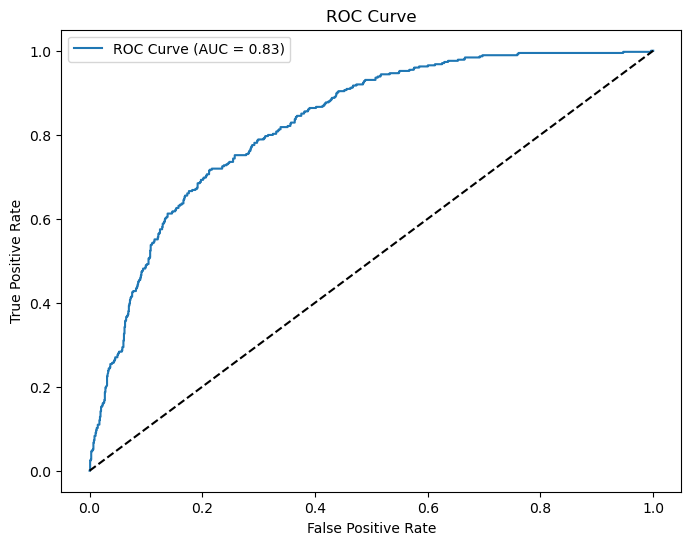

In [9]:
#Model for Logistic Regression

#A.1 Logistic Regression - Training
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#A.2 Logistic Regression - Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
y_prob=model.predict_proba(X_test)[:,1]
print(f'ROC AUC Score: {roc_auc_score(y_test, y_prob)}')
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

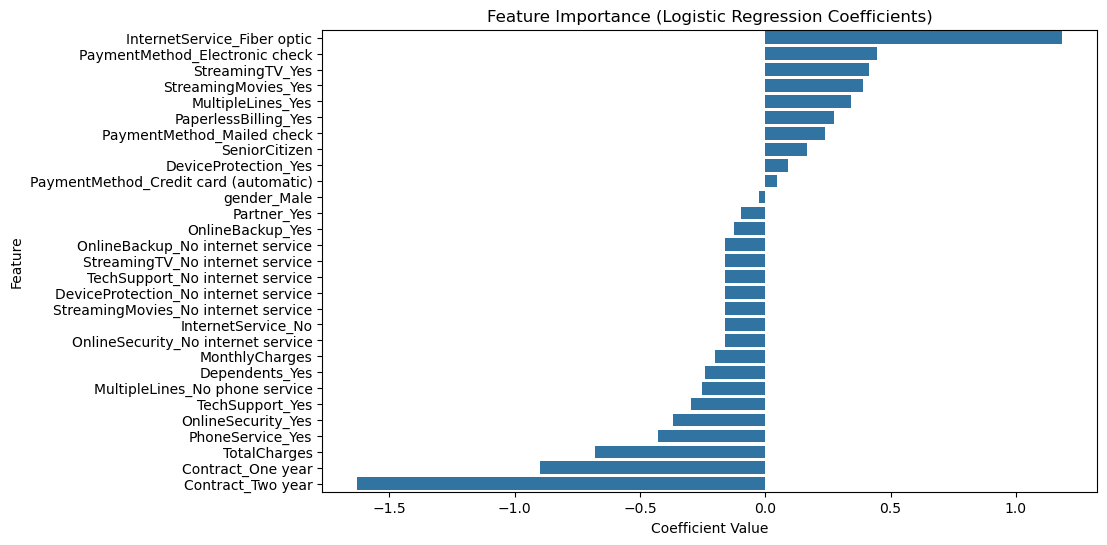

Best Hyperparameters: {'C': 100, 'penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407

[[914 119]
 [171 203]]
ROC AUC Score (Best Model): 0.8250164362145456


In [ ]:
#Additional Steps for Logistic Regression
#A.4 Logistic Regression - Feature Importance
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))      
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()
#based on the feature importance, we can see that 'Contract_Month-to-month' and 'InternetService_Fiber optic' are strong positive predictors of churn, while 'Contract_Two year' is a strong negative predictor. That means customers on month-to-month contracts and those with fiber optic internet are more likely to churn, while those on two-year contracts are less likely to churn. This insight can help the company focus retention efforts on at-risk customers.

#A.5 Logistic Regression - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2']}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
print(f'Best Hyperparameters: {grid_search.best_params_}')
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
y_prob_best = best_model.predict_proba(X_test)[:,1]
print(f'ROC AUC Score (Best Model): {roc_auc_score(y_test, y_prob_best)}')


In [ ]:
#SVM....